In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)
import math
import import_ipynb
import missingno as msno

In [3]:
df=pd.read_csv('Data_Sets/actual_data.csv')
df=df[df["total_volume"]!=-1]
df.interpolate(method="linear",inplace=True,limit_direction="backward")

df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

FileNotFoundError: [Errno 2] No such file or directory: 'Data_Sets/actual_data.csv'

In [4]:
print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

NameError: name 'numerical_cols' is not defined

## *Partial Correlation*

In [8]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import statsmodels.api as sm
from statsmodels.stats.correlation_tools import corr_nearest, corr_clipped
import warnings
from itertools import combinations
import requests
from io import StringIO

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression

from scipy.stats import shapiro
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
import math
import os

### *Calculate Partial Correlation* 

In [ ]:
%pwd
os.chdir("../")
%pwd

In [11]:
from utils import (calculate_partial_correlation,
                    perform_within_p_color_correlations,
                    create_dummy_variables,
                    analyze_p_color_effects,
                    perform_within_p_color_correlations)

PCA Tutorial - Part 3: Component Selection and Quality Assessment
-----------------------------------------------------------------


### *Analyze p_color effects on correlations*


 EXECUTING PARTIAL CORRELATION ANALYSIS

 Step 2: Analyzing p_color effects on pepper morphology

p_color EFFECTS ON Pepper MORPHOLOGY CORRELATIONS
p_color dummy variables created:
  • p_color_red
  • p_color_yellow

Analyzing relationships with and without p_color control:

Price ↔ Demand
--------------

Calculating partial correlation:
X variable: price
Y variable: demand
Controlling for: p_color_red, p_color_yellow
Sample size: 1215

Method 1: Regression Residuals Approach
---------------------------------------------
Partial correlation (residuals method): -0.2275
P-value: 0.000000

Significance test:
Degrees of freedom: 1211
t-statistic: -8.1288
p-value: 0.000000
Effect size: Small

Summary:
Simple correlation:    r = 0.3335 (p = 0.0000)
Partial correlation:   r = -0.2275 (p = 0.0000)
Difference:            Δr = 0.5609
Interpretation: Large p_color effect - p_color is a major confounder

Price ↔ Supply
--------------

Calculating partial correlation:
X variable: price
Y variable:

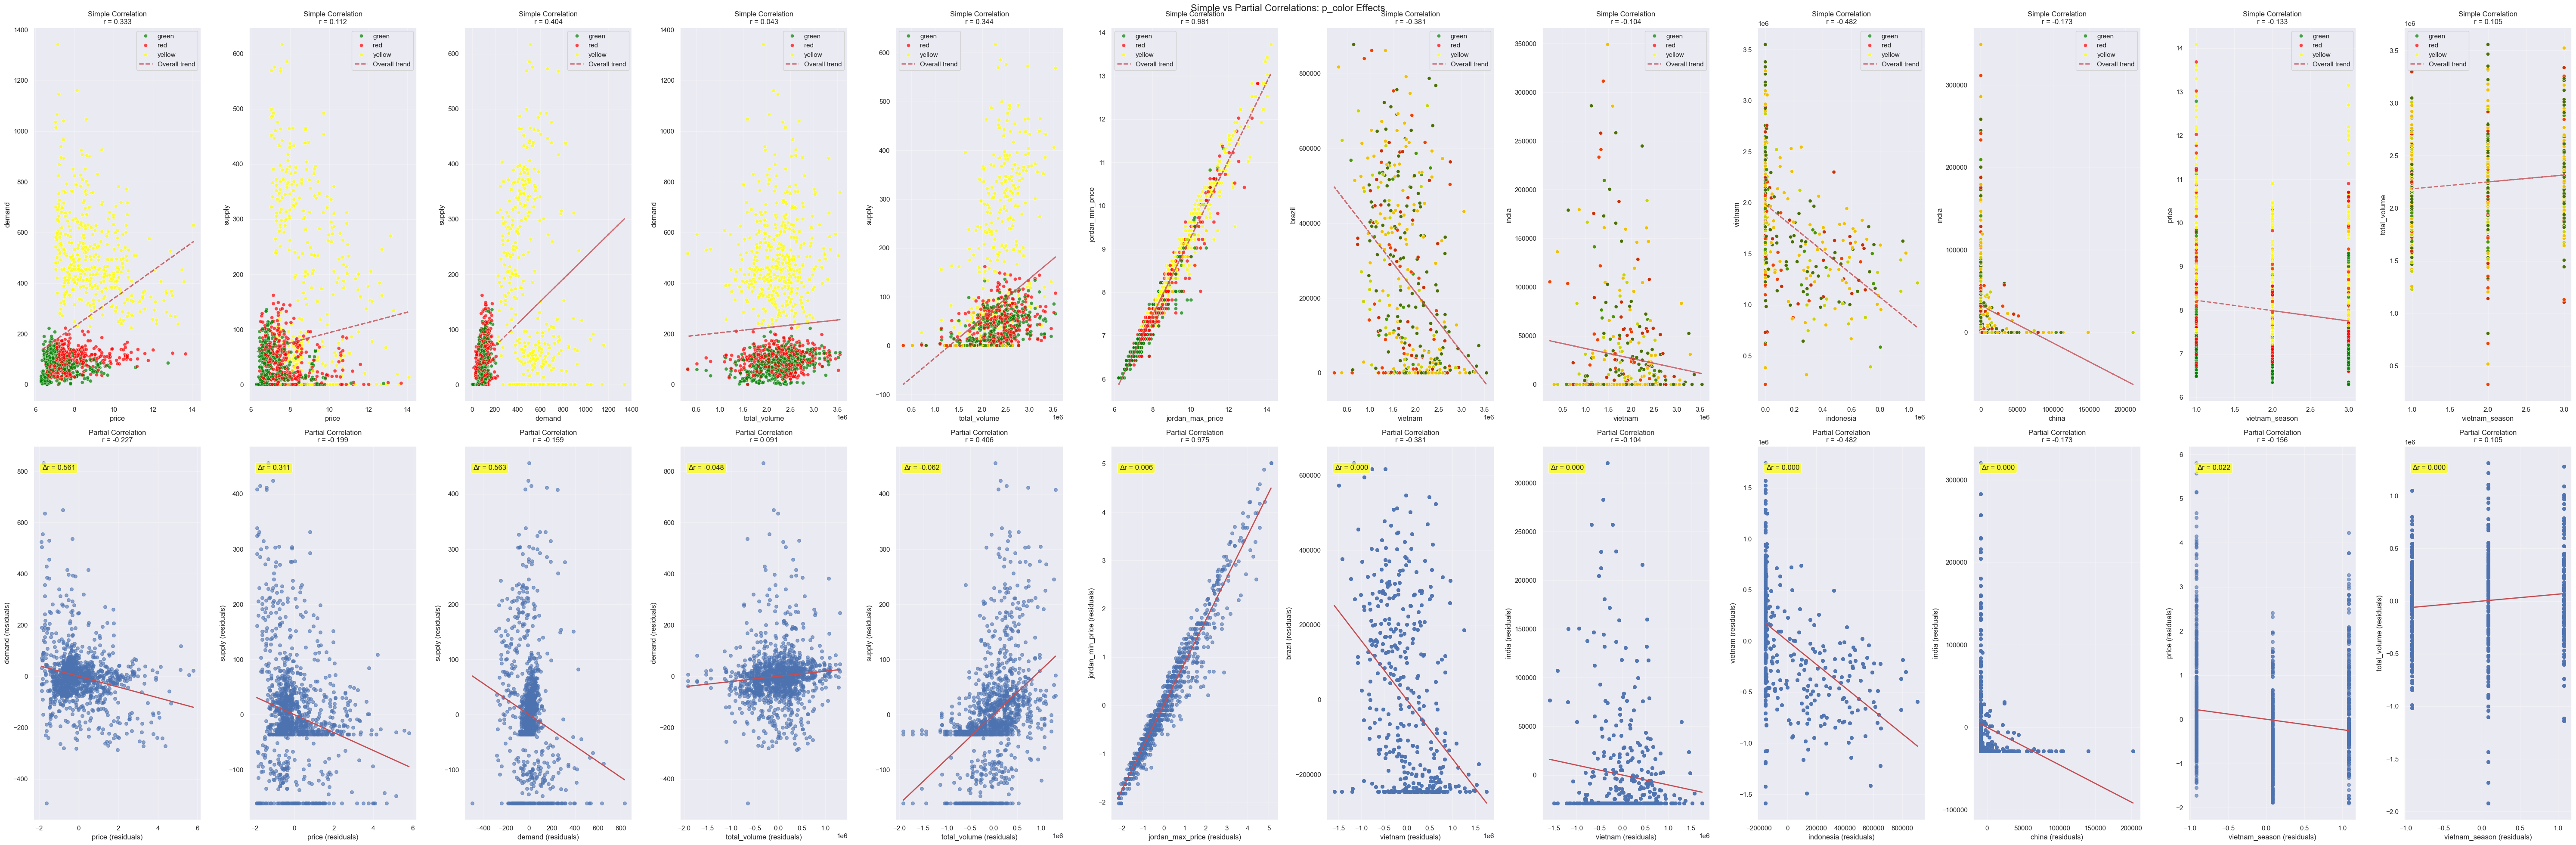

In [6]:
print("\n EXECUTING PARTIAL CORRELATION ANALYSIS")
print("=" * 50)

# Analyze p_color effects on correlations
print("\n Step 2: Analyzing p_color effects on pepper morphology")
p_color_effects = analyze_p_color_effects(df, numerical_cols)

### *Within-p_color correlation analysis*


 Step 3: Within-p_color correlation analysis

WITHIN-P_COLOR CORRELATION ANALYSIS
Analyzing correlations within each p_color:

GREEN PEPPER
Sample size: 405

Correlation matrix:
                  vietnam_season  price  total_volume  brazil  india  vietnam  \
vietnam_season             1.000 -0.210         0.105   0.129 -0.173    0.318   
price                     -0.210  1.000        -0.147   0.239  0.198   -0.413   
total_volume               0.105 -0.147         1.000   0.184 -0.336    0.743   
brazil                     0.129  0.239         0.184   1.000 -0.417   -0.381   
india                     -0.173  0.198        -0.336  -0.417  1.000   -0.104   
vietnam                    0.318 -0.413         0.743  -0.381 -0.104    1.000   
indonesia                 -0.612  0.389         0.108   0.371 -0.225   -0.482   
china                     -0.210  0.186         0.178   0.108 -0.173   -0.105   
jordan_max_price          -0.253  0.913        -0.188   0.181  0.278   -0.416   
jordan_min_

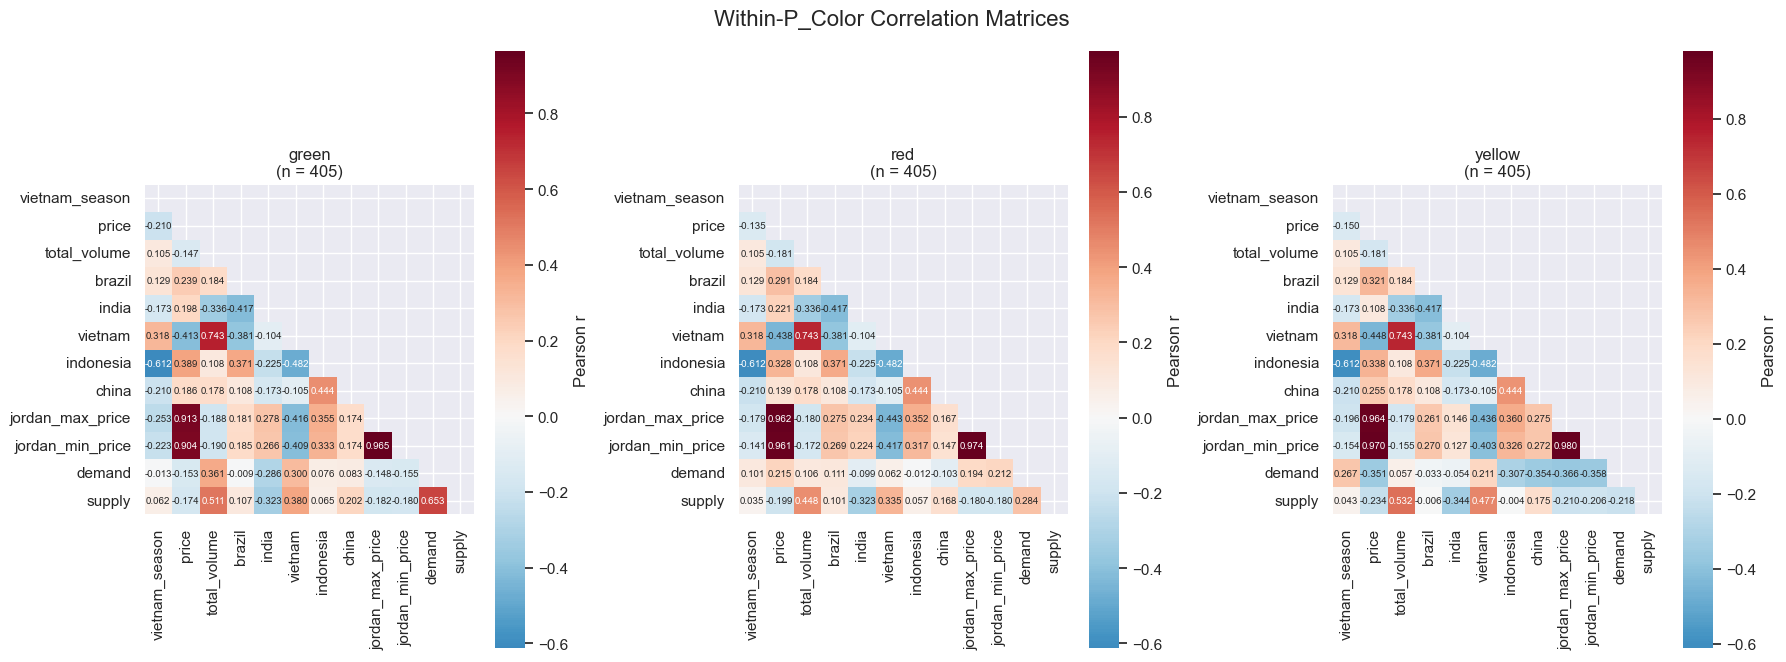


Comparison across p_color:
------------------------------
                                  green       red    yellow
vietnam_season ↔ price        -0.210375 -0.135472 -0.149944
vietnam_season ↔ total_volume  0.104829  0.104829  0.104829
vietnam_season ↔ brazil        0.128824  0.128824  0.128824
vietnam_season ↔ india        -0.173285 -0.173285 -0.173285
vietnam_season ↔ vietnam       0.318449  0.318449  0.318449
...                                 ...       ...       ...
jordan_max_price ↔ demand     -0.148369  0.194154 -0.365524
jordan_max_price ↔ supply     -0.181809 -0.179767 -0.210113
jordan_min_price ↔ demand     -0.154561  0.211662 -0.358045
jordan_min_price ↔ supply     -0.180468 -0.180385 -0.205614
demand ↔ supply                 0.65261  0.283864 -0.218138

[66 rows x 3 columns]

Variability in correlations across p_color:
---------------------------------------------
vietnam_season ↔ price             : variance = 0.0011, range = 0.075
vietnam_season ↔ total_volume      : 

In [7]:
# Within-p_color correlation analysis
print("\n Step 3: Within-p_color correlation analysis")
within_p_color_results, p_color_comparison = perform_within_p_color_correlations(df, numerical_cols)

### *Comprehensive correlation matrix analysis with confidence intervals ,and creating advanced correlation visualizations*

In [15]:
from utils import (fishers_z_transform,
                   inverse_fishers_z,
                   correlation_confidence_interval,comprehensive_correlation_matrix_analysis,create_advanced_correlation_visualizations,
                   hierarchical_clustering_correlations,bootstrap_correlation_confidence_intervals,
                   power_analysis_correlation,practical_correlation_reporting_guide)

In [16]:
# Calculating confidence intervals to pearson r using Fisher's Z-transform
# 1. Convert the correlation r to Fisher’s Z-space where it’s approximately normally distributed.
# once normally distributed, we can use standard techniques for confidence intervals.
# 2. Calculate the standard error (SE) in Z-space using the sample size n.
# 3. Build a confidence interval in Z-space using a critical value from the normal distribution.
# 4. Convert the interval back to the correlation scale using the inverse Fisher transformation.

#Correlation matrix analysis
# 1. Calculate Pairwise Pearson Correlations: For each pair of continuous variables,
# compute the correlation coefficient and its p-value, along with the sample size used.

# 2. Build Confidence Intervals for Each Correlation: Using Fisher's Z transformation,
# estimate confidence intervals (default 95%) for the correlation values, helping you gauge the uncertainty.
# It's like calculating 3 correlation matrices, one we had before and two more - lower and upper uncertainties

# 3. Store and Display Results: Organize the raw correlations, p-values, CI bounds,
# and sample sizes into matrices and also prints detailed stats for each unique pair.

# 4. Apply Multiple Comparisons Correction: To control the false discovery rate across
# all pairwise tests, adjust p-values using methods like Bonferroni, Holm, and
# FDR (Benjamini-Hochberg/Yekutieli), and report how many remain statistically significant.


# Hierarchical Clustering of Correlation Matrix
# 1. Convert Correlations to Distances: Transform the correlation matrix into a distance matrix using the formula:
# Distance = 1 −∣correlation∣ - This way, variables that are highly correlated (positive or negative) are considered “close.”

# 2. Perform Hierarchical Clustering: Apply hierarchical clustering (Ward's method) to group similar variables based on their
# pairwise distances — identifying natural clusters of correlated variables.

# 3. Visualize the Results: Plot a dendrogram showing how variables cluster hierarchically.
# Reorder and plot the correlation matrix based on clustering so related variables are grouped visually in blocks.

# 4. Print Cluster Groupings at Multiple Levels: Show which variables fall into 2, 3, or 4 clusters,
# helping us interpret the structure at different granularity levels.

# Bootstrap Confidence Intervals for Correlation
# 1. Calculate the Original Correlation: Compute the Pearson correlation and p-value
# between two variables using the original dataset (after dropping missing values).

# 2. Generate a Bootstrap Distribution: Repeatedly resample the data with replacement
# to create many new datasets, compute correlation for each, and build a distribution of correlation values.

# 3. Compute Bootstrap Confidence Intervals: Use the percentile method (e.g., 2.5th and 97.5th percentiles for 95% CI)
# to estimate a confidence interval from the bootstrap distribution.
# Also compare this to the Fisher’s Z-based confidence interval.

# 4. Visualize and Report Key Statistics: Plot the bootstrap distribution, highlight key values like the original correlation,
# bootstrap mean, and confidence bounds, and shows a Q-Q plot to assess normality of the bootstrap distribution.
# Also report bias and standard deviation of the bootstrap estimate.

# Power Analysis for Correlation Studies

# 1. Estimate Required Sample Sizes for Desired Power: For a given target power (e.g. 80%), calculate how many samples
# we need to detect various correlation strengths (e.g., small = 0.1, medium = 0.3, large = 0.5) using Fisher’s Z transformation.

# 2. Compute Statistical Power Across Sample Sizes and Effect Sizes: Calculate and plot how power increases as
# sample size increases for fixed correlation levels — helping us see when our study becomes adequately powered.

# 3. Visualize Critical Trade-offs
# Generate four key plots:
#   i. Power vs Sample Size for various effect sizes
#   ii. Sample Size vs Effect Size for achieving target power
#   iii. Power vs Effect Size for different sample sizes
#   iv. Minimum Detectable Correlation for a range of sample sizes at fixed power

# 4. Highlight Cohen’s Guidelines: Overlay visual benchmarks (small, medium, large effects) to help us interpret results
# using widely accepted effect size categories.



 EXECUTING ADVANCED CORRELATION ANALYSIS

 Step 1: Comprehensive correlation matrix analysis with confidence intervals

COMPREHENSIVE CORRELATION MATRIX ANALYSIS
Calculating correlations with 95% confidence intervals:
------------------------------------------------------------
vietnam_season ↔ price:
  r =  -0.133 [-0.188, -0.078], p =  0.0000, n = 1215
vietnam_season ↔ total_volume:
  r =   0.105 [ 0.049,  0.160], p =  0.0003, n = 1215
vietnam_season ↔ brazil:
  r =   0.129 [ 0.073,  0.184], p =  0.0000, n = 1215
vietnam_season ↔ india:
  r =  -0.173 [-0.227, -0.118], p =  0.0000, n = 1215
vietnam_season ↔ vietnam:
  r =   0.318 [ 0.267,  0.368], p =  0.0000, n = 1215
vietnam_season ↔ indonesia:
  r =  -0.612 [-0.646, -0.575], p =  0.0000, n = 1215
vietnam_season ↔ china:
  r =  -0.210 [-0.263, -0.155], p =  0.0000, n = 1215
vietnam_season ↔ jordan_max_price:
  r =  -0.175 [-0.229, -0.119], p =  0.0000, n = 1215
vietnam_season ↔ jordan_min_price:
  r =  -0.139 [-0.194, -0.084], p = 

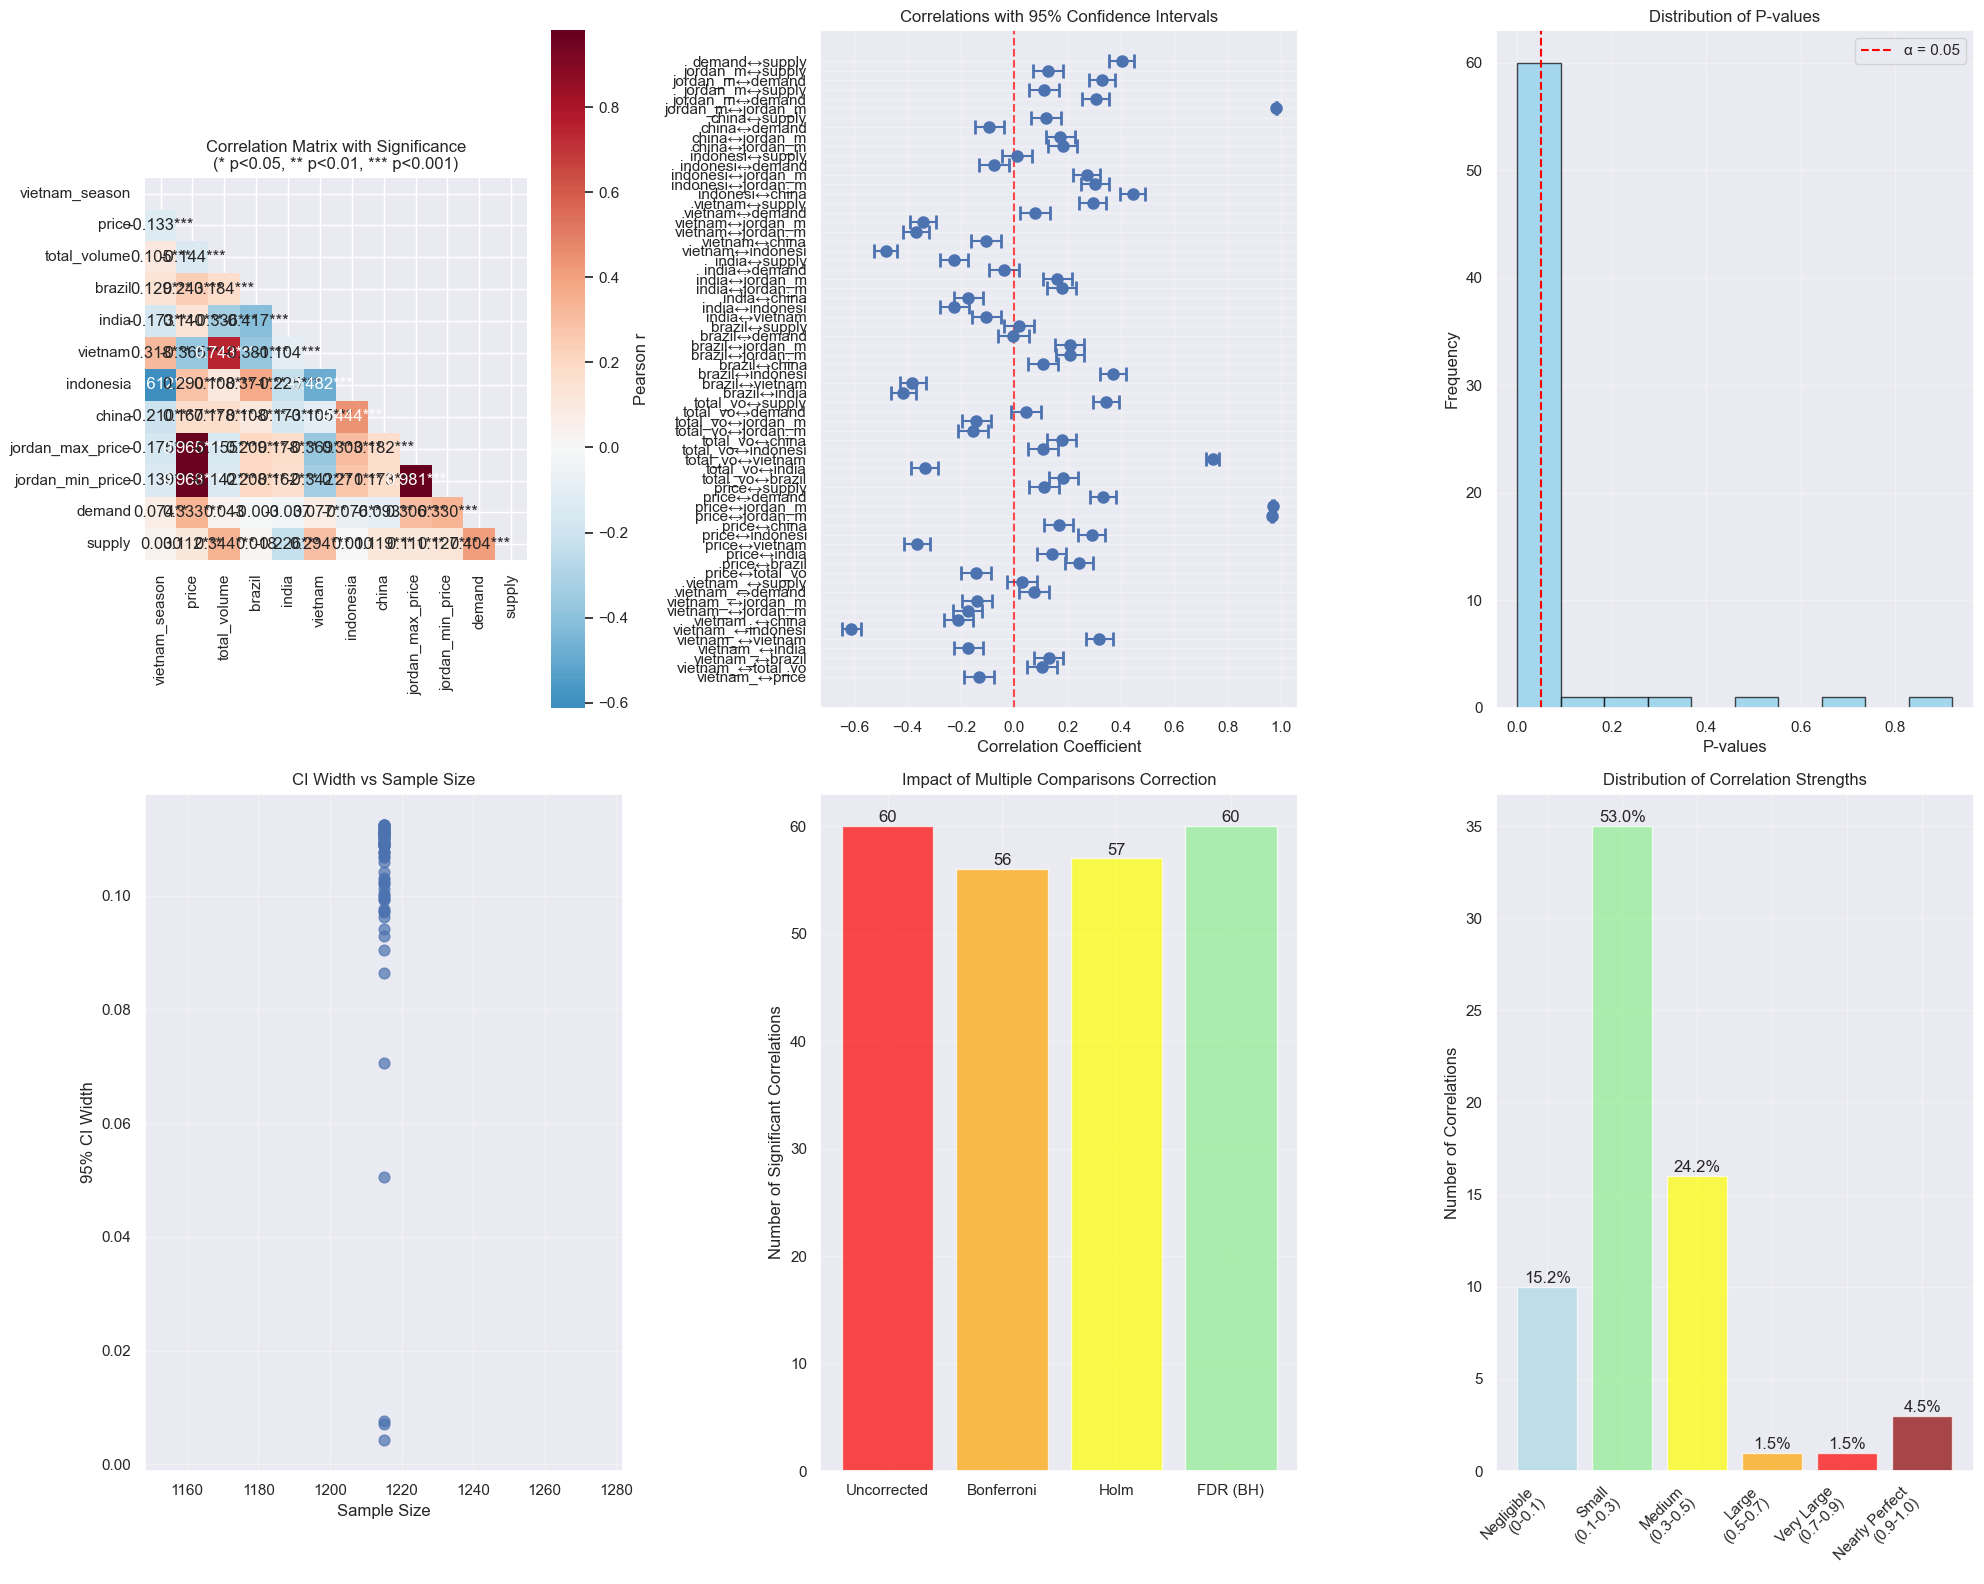

In [17]:
# Execute Part 4 Analysis
print("\n EXECUTING ADVANCED CORRELATION ANALYSIS")
print("=" * 55)

# Step 1: Comprehensive correlation matrix analysis
print("\n Step 1: Comprehensive correlation matrix analysis with confidence intervals")
comprehensive_analysis = comprehensive_correlation_matrix_analysis(df, numerical_cols)

# Step 2: Advanced visualizations
print("\n Step 2: Creating advanced correlation visualizations")
create_advanced_correlation_visualizations(comprehensive_analysis, numerical_cols)